In [3]:
# 07_feature_vs_performance.ipynb
# Full experiment: train LR and MLP for top-k features where k=1..13
# Saves metrics CSV and plots. Configure SAVE_MODELS_FOR_K below.

import os, time, json, joblib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path("..")
DATA_PATH = ROOT / "data" / "heart_uci.csv"
ART_DIR = ROOT / "artifacts"
MODELS_DIR = ART_DIR / "models_feature_vs_k"
FIG_DIR = ROOT / "figures"
FEATURE_MAP = ART_DIR / "feature_index_map.json"          # or use feature_importance_mean.csv
TOPK_XGB_CSV = ART_DIR / "topk_results.csv"               # XGB results you already have (optional)

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Experiment config
RANDOM_STATE = 42
N_SPLITS_CV = 5
N_REPEATS_PER_K = 1   # set >1 for repeated trials (adds runtime)
SAVE_LR_MODELS = True
SAVE_MLP_MODELS_FOR_K = [7, 13]   # save only for these k to avoid huge storage; change as needed
VERBOSE = 1
N_JOBS = -1   # for GridSearchCV

OUT_CSV = ART_DIR / "feature_vs_perf_all_models.csv"
print("Artifacts will be written to:", ART_DIR)

Artifacts will be written to: ..\artifacts


In [4]:
# helpers
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
import math, json

def ece_score(y_true, probs, n_bins=10):
    df = pd.DataFrame({"y": y_true, "p": probs})
    bins = np.linspace(0.0, 1.0, n_bins+1)
    df["bin"] = pd.cut(df["p"], bins=bins, include_lowest=True)
    tab = df.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()
    tab["abs_err"] = (tab["mean_pred"] - tab["frac_pos"]).abs()
    if tab["n"].sum() == 0:
        return np.nan
    return (tab["n"] * tab["abs_err"]).sum() / tab["n"].sum()

def save_metrics_row(outfile, row):
    df = pd.DataFrame([row])
    if not outfile.exists():
        df.to_csv(outfile, index=False)
    else:
        df_existing = pd.read_csv(outfile)
        df_existing = pd.concat([df_existing, df], ignore_index=True)
        df_existing.to_csv(outfile, index=False)

In [5]:
# Load raw dataset and create holdout split (same as previous notebooks)
df = pd.read_csv(DATA_PATH)
df['num'] = (df['num'] > 0).astype(int)
X_raw = df.drop(columns=['num']).copy()
y = df['num'].values

from sklearn.model_selection import train_test_split
X_train_df, X_hold_df, y_train, y_hold = train_test_split(X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train / hold sizes:", X_train_df.shape, X_hold_df.shape)

# Recreate preprocessor (exact same as earlier notebooks)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = ['age','trestbps','chol','thalch','oldpeak','ca']
categorical_features = ['sex','cp','fbs','restecg','exang','slope','thal']
categories_list = [sorted(X_raw[c].dropna().unique().tolist()) for c in categorical_features]

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, categories=categories_list))])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop", sparse_threshold=0)

# fit preprocessor on train only
preprocessor.fit(X_train_df)

# get full transformed names
def get_feature_names(ct):
    names=[]
    for name, transformer, cols in ct.transformers_:
        if name == "remainder": continue
        if hasattr(transformer, "named_steps"):
            last = list(transformer.named_steps.values())[-1]
            if hasattr(last, "get_feature_names_out"):
                out = last.get_feature_names_out(cols)
                names.extend(out.tolist())
            else:
                names.extend(list(cols))
        else:
            if hasattr(transformer, "get_feature_names_out"):
                names.extend(transformer.get_feature_names_out(cols).tolist())
            else:
                names.extend(list(cols))
    return names

full_feature_names = get_feature_names(preprocessor)
print("Total transformed features:", len(full_feature_names))
print(full_feature_names)

# load ranked features (use feature_index_map.json if present)
if Path(FEATURE_MAP).exists():
    meta = json.load(open(FEATURE_MAP))
    ranked_features = meta.get("full_feature_names", full_feature_names)
    selected_ranked = meta.get("selected_features", None)
    # if meta contains ranking by 'feature_importance_mean.csv', use that ordering
    if Path(ART_DIR/"feature_importance_mean.csv").exists():
        mean_imp = pd.read_csv(ART_DIR/"feature_importance_mean.csv")
        ranked_features = mean_imp.sort_values("rank")['feature'].tolist()
else:
    # fallback: try feature_importance_mean.csv
    if Path(ART_DIR/"feature_importance_mean.csv").exists():
        mean_imp = pd.read_csv(ART_DIR/"feature_importance_mean.csv")
        ranked_features = mean_imp.sort_values("rank")['feature'].tolist()
    else:
        raise FileNotFoundError("No feature_index_map.json nor feature_importance_mean.csv found in artifacts. Provide ranking.")

print("Top-ranked features (preview):", ranked_features[:10])

Train / hold sizes: (736, 15) (184, 15)
Total transformed features: 25
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_False', 'fbs_True', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'exang_False', 'exang_True', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect']
Top-ranked features (preview): ['cp_asymptomatic', 'exang_False', 'cp_atypical angina', 'chol', 'sex_Female', 'oldpeak', 'thal_normal', 'age', 'ca', 'slope_upsloping']


In [11]:
# Prepare transformed matrices (dense numpy)
X_train_trans = preprocessor.transform(X_train_df)
X_hold_trans = preprocessor.transform(X_hold_df)

# Create DataFrames for easy column selection by name
X_train_trans_df = pd.DataFrame(X_train_trans, columns=full_feature_names, index=X_train_df.index)
X_hold_trans_df  = pd.DataFrame(X_hold_trans, columns=full_feature_names, index=X_hold_df.index)

# Prepare CSV: clear if exists
if OUT_CSV.exists():
    OUT_CSV.unlink()
print("Output CSV will be:", OUT_CSV)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# MLP builder (small)
def build_mlp(input_dim, hidden=[64,32], dropout=0.25, lr=1e-3):
    model = Sequential()
    model.add(Dense(hidden[0], activation='relu', input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    for h in hidden[1:]:
        model.add(Dense(h, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
    return model

Output CSV will be: ..\artifacts\feature_vs_perf_all_models.csv


In [13]:
# Main loop
ks = list(range(1, 14))  # 1..13
cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE)

for repeat in range(N_REPEATS_PER_K):
    seed = RANDOM_STATE + repeat
    np.random.seed(seed)
    print(f"=== Repeat {repeat+1}/{N_REPEATS_PER_K}, seed={seed} ===")
    for k in ks:
        t_start_k = time.time()
        topk = ranked_features[:k]
        print(f"\n--- k={k}, features: {topk} ---")

        # Prepare train / hold matrices for this k
        Xtr_k = X_train_trans_df[topk].values
        Xhd_k = X_hold_trans_df[topk].values

        # ---- Logistic Regression (CV grid) ----
        lr = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=seed)
        param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}  # same small grid as before
        gs = GridSearchCV(lr, param_grid, scoring='roc_auc', cv=cv, n_jobs=N_JOBS, verbose=VERBOSE)
        t0 = time.time()
        gs.fit(Xtr_k, y_train)
        t1 = time.time()
        best_lr = gs.best_estimator_
        probs_lr = best_lr.predict_proba(Xhd_k)[:,1]
        roc_lr = roc_auc_score(y_hold, probs_lr)
        ap_lr = average_precision_score(y_hold, probs_lr)
        brier_lr = brier_score_loss(y_hold, probs_lr)
        ece_lr = ece_score(y_hold, probs_lr)
        lr_train_time = t1 - t0

        # optionally save LR model artifact
        if SAVE_LR_MODELS:
            lr_path = MODELS_DIR / f"lr_k{k}.joblib"
            joblib.dump(best_lr, lr_path)

        # ---- MLP ----
        # Build model
        mlp = build_mlp(input_dim=Xtr_k.shape[1], hidden=[64,32], dropout=0.25)
        # callbacks
        model_fname = MODELS_DIR / f"mlp_k{k}.h5"
        es = EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True, verbose=0)
        mc = ModelCheckpoint(str(model_fname), monitor='val_auc', mode='max', save_best_only=True, verbose=0)
        t0 = time.time()
        history = mlp.fit(Xtr_k, y_train, validation_split=0.15, epochs=200, batch_size=32, callbacks=[es,mc], verbose=0)
        t1 = time.time()
        # load best model
        try:
            import tensorflow as tf
            best_mlp = tf.keras.models.load_model(str(model_fname))
        except Exception:
            best_mlp = mlp  # fallback
        probs_mlp = best_mlp.predict(Xhd_k).ravel()
        roc_mlp = roc_auc_score(y_hold, probs_mlp)
        ap_mlp = average_precision_score(y_hold, probs_mlp)
        brier_mlp = brier_score_loss(y_hold, probs_mlp)
        ece_mlp = ece_score(y_hold, probs_mlp)
        mlp_train_time = t1 - t0
        # optionally save mlp only for chosen k values (avoid huge disk usage)
        if k in SAVE_MLP_MODELS_FOR_K:
            best_mlp.save(MODELS_DIR / f"mlp_k{k}_saved.keras")

        # ---- record metrics row ----
        row = {
            "seed": seed,
            "k": k,
            "features": ";".join(topk),
            # LR
            "model": "LR",
            "roc_auc": float(roc_lr), "avg_precision": float(ap_lr),
            "brier": float(brier_lr), "ece": float(ece_lr),
            "train_time_s": float(lr_train_time),
            "model_artifact": str(MODELS_DIR / f"lr_k{k}.joblib") if SAVE_LR_MODELS else ""
        }
        save_metrics_row(OUT_CSV, row)

        row = {
            "seed": seed,
            "k": k,
            "features": ";".join(topk),
            "model": "MLP",
            "roc_auc": float(roc_mlp), "avg_precision": float(ap_mlp),
            "brier": float(brier_mlp), "ece": float(ece_mlp),
            "train_time_s": float(mlp_train_time),
            "model_artifact": str(MODELS_DIR / f"mlp_k{k}.h5") if (k in SAVE_MLP_MODELS_FOR_K) else ""
        }
        save_metrics_row(OUT_CSV, row)

        t_end_k = time.time()
        print(f"k={k} done in {t_end_k - t_start_k:.1f}s; LR roc={roc_lr:.4f}, MLP roc={roc_mlp:.4f}")

print("All k done. Metrics saved to:", OUT_CSV)

=== Repeat 1/1, seed=42 ===

--- k=1, features: ['cp_asymptomatic'] ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\Nikhil\AppData\Local\Temp\ipykernel_13436\2800068868.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()
C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
k=1 done in 16.3s; LR roc=0.8069, MLP roc=0.8069

--- k=2, features: ['cp_asymptomatic', 'exang_False'] ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\Nikhil\AppData\Local\Temp\ipykernel_13436\2800068868.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()
C:\Users\Nikhil\AppData\Local\Temp\ipykernel_13436\2800068868.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()
C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When usi

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
k=2 done in 17.2s; LR roc=0.8626, MLP roc=0.8620

--- k=3, features: ['cp_asymptomatic', 'exang_False', 'cp_atypical angina'] ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits


...

C:\Users\Nikhil\AppData\Local\Temp\ipykernel_13436\2800068868.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()
C:\Users\Nikhil\AppData\Local\Temp\ipykernel_13436\2800068868.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()


k=12 done in 24.8s; LR roc=0.9100, MLP roc=0.9137

--- k=13, features: ['cp_asymptomatic', 'exang_False', 'cp_atypical angina', 'chol', 'sex_Female', 'oldpeak', 'thal_normal', 'age', 'ca', 'slope_upsloping', 'thalch', 'fbs_False', 'restecg_normal'] ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
k=13 done in 28.5s; LR roc=0.9073, MLP roc=0.9182
All k done. Metrics saved to: ..\artifacts\feature_vs_perf_all_models.csv


C:\Users\Nikhil\AppData\Local\Temp\ipykernel_13436\2800068868.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()


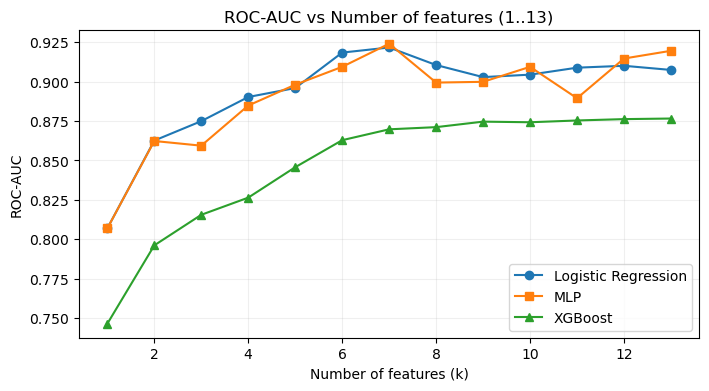

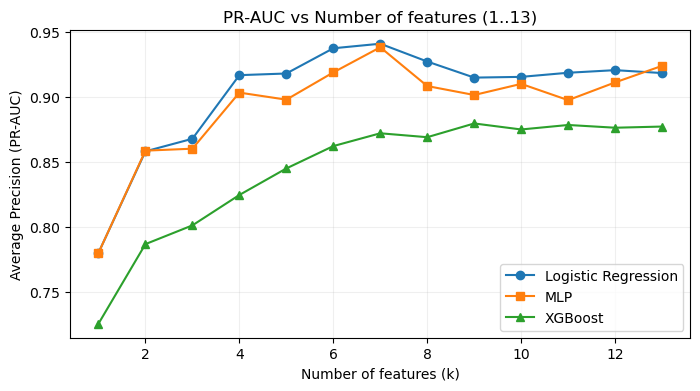

In [18]:
# Robust plotting for ROC-AUC vs k and PR-AUC vs k
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df_all = pd.read_csv(OUT_CSV)

# prepare LR and MLP aggregated (take mean over seeds if present)
df_lr = df_all[df_all['model']=="LR"].groupby('k').agg({'roc_auc':'mean','avg_precision':'mean'}).reset_index().sort_values('k')
df_mlp = df_all[df_all['model']=="MLP"].groupby('k').agg({'roc_auc':'mean','avg_precision':'mean'}).reset_index().sort_values('k')

plt.figure(figsize=(8,4))
plt.plot(df_lr['k'], df_lr['roc_auc'], marker='o', label='Logistic Regression')
plt.plot(df_mlp['k'], df_mlp['roc_auc'], marker='s', label='MLP')

# safe load of XGB CSV: try a few common column name variants
xgb_path = Path(TOPK_XGB_CSV)
if xgb_path.exists():
    df_xgb_raw = pd.read_csv(xgb_path)
    # find column names for k and roc-like
    possible_k_cols = [c for c in df_xgb_raw.columns if c.lower() in ('k','n_features','num_features','n')]
    possible_roc_cols = [c for c in df_xgb_raw.columns if 'auc' in c.lower() or 'roc' in c.lower() or 'mean_auc' in c.lower()]
    if not possible_k_cols:
        print("Warning: couldn't find 'k' column in XGB CSV. Columns:", df_xgb_raw.columns.tolist())
    else:
        kcol = possible_k_cols[0]
        # choose roc column
        roccol = possible_roc_cols[0] if possible_roc_cols else None
        # coerce to numeric safely
        df_xgb = df_xgb_raw.copy()
        df_xgb[kcol] = pd.to_numeric(df_xgb[kcol], errors='coerce')
        if roccol is not None:
            df_xgb[roccol] = pd.to_numeric(df_xgb[roccol], errors='coerce')
            df_xgb = df_xgb.dropna(subset=[kcol, roccol])
            df_xgb = df_xgb[df_xgb[kcol] <= 13].sort_values(kcol)
            plt.plot(df_xgb[kcol].astype(int), df_xgb[roccol], marker='^', label='XGBoost')
        else:
            print("Warning: no roc-like column found in XGB CSV. Columns:", df_xgb_raw.columns.tolist())

plt.xlabel("Number of features (k)")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC vs Number of features (1..13)")
plt.legend()
plt.grid(alpha=0.2)
plt.savefig(FIG_DIR / "roc_vs_k_all_models.png", dpi=250)
plt.show()

# PR-AUC plot (same approach)
plt.figure(figsize=(8,4))
plt.plot(df_lr['k'], df_lr['avg_precision'], marker='o', label='Logistic Regression')
plt.plot(df_mlp['k'], df_mlp['avg_precision'], marker='s', label='MLP')
if xgb_path.exists() and 'possible_roc_cols' in locals():
    # try to find a PR column
    possible_pr_cols = [c for c in df_xgb_raw.columns if 'precision' in c.lower() or 'avg_precision' in c.lower() or 'pr' in c.lower()]
    if possible_pr_cols:
        prcol = possible_pr_cols[0]
        df_xgb[prcol] = pd.to_numeric(df_xgb[prcol], errors='coerce')
        df_xgb_pr = df_xgb.dropna(subset=[prcol])
        plt.plot(df_xgb_pr[kcol].astype(int), df_xgb_pr[prcol], marker='^', label='XGBoost')
    else:
        print("No PR-like column found in XGB CSV; skipping XGB PR curve.")
plt.xlabel("Number of features (k)")
plt.ylabel("Average Precision (PR-AUC)")
plt.title("PR-AUC vs Number of features (1..13)")
plt.legend()
plt.grid(alpha=0.2)
plt.savefig(FIG_DIR / "pr_vs_k_all_models.png", dpi=250)
plt.show()

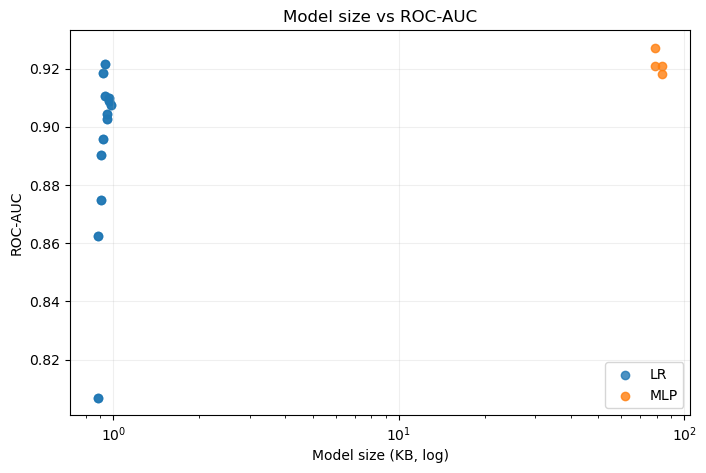

In [19]:
# Robust model size vs ROC scatter
import math, os
df_metrics = pd.read_csv(OUT_CSV)

# safe extraction of sizes
sizes = []
for art in df_metrics.get('model_artifact', pd.Series(dtype=object)).astype(object):
    # art might be NaN (float) or empty string
    if isinstance(art, float) and math.isnan(art):
        sizes.append(math.nan)
    elif art is None:
        sizes.append(math.nan)
    else:
        art_str = str(art)
        if art_str.strip() == "" or art_str.lower() in ("nan","none"):
            sizes.append(math.nan)
        else:
            # If relative path, make it absolute relative to notebook root
            p = Path(art_str)
            if not p.exists():
                # try relative to artifacts dir
                p2 = Path(ART_DIR) / Path(art_str).name
                if p2.exists():
                    sizes.append(p2.stat().st_size)
                else:
                    sizes.append(math.nan)
            else:
                sizes.append(p.stat().st_size)
df_metrics['model_size_bytes'] = sizes

# Plot
plt.figure(figsize=(8,5))
for model in df_metrics['model'].unique():
    sub = df_metrics[df_metrics['model']==model]
    plt.scatter(sub['model_size_bytes']/1024, sub['roc_auc'], label=model, alpha=0.8)
plt.xscale('log')
plt.xlabel("Model size (KB, log)")
plt.ylabel("ROC-AUC")
plt.title("Model size vs ROC-AUC")
plt.legend()
plt.grid(alpha=0.2)
plt.savefig(FIG_DIR / "size_vs_roc_all_models.png", dpi=250)
plt.show()

In [6]:
# RUN THIS to inspect your XGB CSV structure
from pathlib import Path
import pandas as pd
p = Path(TOPK_XGB_CSV)
print("Exists:", p.exists(), "Path:", p)
if p.exists():
    df_xgb_raw = pd.read_csv(p)
    print("XGB CSV columns:", df_xgb_raw.columns.tolist())
    print("Sample rows:\n", df_xgb_raw.head(8))
    # try to coerce n_features to numeric and display dtype
    if 'n_features' in df_xgb_raw.columns:
        print("n_features dtype:", df_xgb_raw['n_features'].dtype)
    if 'k' in df_xgb_raw.columns:
        print("k dtype:", df_xgb_raw['k'].dtype)


Exists: True Path: ..\artifacts\topk_results.csv
XGB CSV columns: ['k', 'n_features', 'mean_auc', 'std_auc', 'mean_avg_precision', 'std_avg_precision', 'model_path', 'model_size_bytes']
Sample rows:
    k  n_features  mean_auc   std_auc  mean_avg_precision  std_avg_precision  \
0  1           1  0.746478  0.019083            0.725714           0.018242   
1  2           2  0.796148  0.016161            0.786846           0.011559   
2  3           3  0.815519  0.014226            0.801245           0.007238   
3  4           4  0.826400  0.017390            0.824588           0.019102   
4  5           5  0.845679  0.024437            0.844967           0.025363   
5  6           6  0.862814  0.025884            0.862136           0.013885   
6  7           7  0.869705  0.024327            0.871968           0.023711   
7  8           8  0.871085  0.030206            0.868956           0.037851   

                                      model_path  model_size_bytes  
0  ../artifacts/top

In [8]:
# Load raw df, reproduce the split
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("../data/heart_uci.csv")
df['num'] = (df['num']>0).astype(int)
X = df.drop(columns=['num'])
y = df['num'].values
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train/hold shapes:", X_train.shape, X_hold.shape)

Train/hold shapes: (736, 15) (184, 15)


In [11]:
import joblib, numpy as np, pandas as pd
from pathlib import Path

# load df and recreate split (same as before)
df = pd.read_csv("../data/heart_uci.csv")
df['num'] = (df['num']>0).astype(int)
X = df.drop(columns=['num'])
y = df['num'].values
from sklearn.model_selection import train_test_split
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# load saved preprocessor - DO NOT print it
preproc_p = Path("../artifacts/preprocessor_initial.joblib")
print("preprocessor exists:", preproc_p.exists())
preproc = joblib.load(str(preproc_p))

# if getattr missing triggers repr error, avoid printing. Just test transform
X_hold_trans = preproc.transform(X_hold)   # if this runs, transformer is usable
print("Transformed holdout shape:", X_hold_trans.shape)

preprocessor exists: True
Transformed holdout shape: (184, 25)


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.3.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.3.0 when using vers

In [17]:
import json, joblib, numpy as np, pandas as pd, os
from pathlib import Path

# load raw df & split (same as before)
df = pd.read_csv("../data/heart_uci.csv")
df['num'] = (df['num'] > 0).astype(int)
X = df.drop(columns=['num']).copy()
y = df['num'].values

from sklearn.model_selection import train_test_split
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# load preprocessor (fitted at training time)
preproc = joblib.load("../artifacts/preprocessor_initial.joblib")
# transform full holdout -> dense numpy
X_hold_trans = preproc.transform(X_hold)   # shape should be (184, 25)
print("X_hold_trans shape:", X_hold_trans.shape)

# get full transformed feature names (helper) - safe version
def get_feature_names(ct):
    names=[]
    for name, transformer, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "named_steps"):
            last = list(transformer.named_steps.values())[-1]
            if hasattr(last, "get_feature_names_out"):
                # last is OneHotEncoder etc.
                out = last.get_feature_names_out(cols)
                names.extend(out.tolist())
            else:
                names.extend(list(cols))
        else:
            if hasattr(transformer, "get_feature_names_out"):
                names.extend(transformer.get_feature_names_out(cols).tolist())
            else:
                names.extend(list(cols))
    return names

full_feature_names = get_feature_names(preproc)
print("Full transformed feature count:", len(full_feature_names))

# load mapping of selected top7 (preferred to use feature_index_map.json created earlier)
meta_path = Path("../artifacts/feature_index_map.json")
if meta_path.exists():
    meta = json.load(open(meta_path))
    top7 = meta["selected_features"]
    top7_indices = meta["selected_indices"]
else:
    # fallback read feature_importance_mean.csv
    mean_imp = pd.read_csv("../artifacts/feature_importance_mean.csv")
    top7 = mean_imp.sort_values("rank")['feature'].tolist()[:7]
    top7_indices = [full_feature_names.index(f) for f in top7]

print("Top7 features:", top7)
print("Top7 indices:", top7_indices)

# create X_hold_top7 array (in the same column order used during training)
X_hold_top7 = X_hold_trans[:, top7_indices]
print("X_hold_top7 shape:", X_hold_top7.shape)

# optional: make a DataFrame with proper column names
X_hold_top7_df = pd.DataFrame(X_hold_top7, columns=top7, index=X_hold.index)
print(X_hold_top7_df.head())


X_hold_trans shape: (184, 25)
Full transformed feature count: 25
Top7 features: ['cp_asymptomatic', 'exang_False', 'cp_atypical angina', 'chol', 'sex_Female', 'oldpeak', 'thal_normal']
Top7 indices: [8, 17, 9, 2, 6, 4, 23]
X_hold_top7 shape: (184, 7)
     cp_asymptomatic  exang_False  cp_atypical angina      chol  sex_Female  \
514              1.0          1.0                 0.0  0.055893         0.0   
825              1.0          0.0                 0.0  0.753263         0.0   
854              1.0          1.0                 0.0  0.551393         0.0   
804              1.0          0.0                 0.0  0.441282         0.0   
887              0.0          1.0                 0.0  0.652328         0.0   

      oldpeak  thal_normal  
514 -0.806886          1.0  
825  2.975714          0.0  
854  1.084414          1.0  
804  2.975714          1.0  
887 -0.334061          1.0  


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.3.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.3.0 when using vers

In [21]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import joblib
import tensorflow as tf
import sys
sys.path.append("..")
from src.transforms import select_cols_top7

# 1) XGB pipeline (expects raw X or pipeline handles preproc internally)
xgb_pipe = joblib.load("../artifacts/final_lightweight_model_k7_clean.joblib")  # pipeline inside calibrated wrapper
probs_xgb = xgb_pipe.predict_proba(X_hold)[:,1]   # pass raw X_hold; pipeline does transforms internally

# 2) LR (expects top7 features only)
lr = joblib.load("../artifacts/lr_top7.joblib")   # this is the LR trained on top7
probs_lr = lr.predict_proba(X_hold_top7_df)[:,1]  # pass DataFrame with column names matching training

# 3) MLP (Keras .h5)
mlp = tf.keras.models.load_model("../artifacts/mlp_top7.h5")
# Keras expects numpy array shape (n_samples, n_features), matching training input scale. We used preproc above.
probs_mlp = mlp.predict(X_hold_top7)[:,0]  # shape (n,1) -> flatten

# compute metrics
for name, p in [("XGB", probs_xgb), ("LR", probs_lr), ("MLP", probs_mlp)]:
    print(name, "ROC-AUC:", roc_auc_score(y_hold, p),
          "AP:", average_precision_score(y_hold, p),
          "Brier:", brier_score_loss(y_hold, p))


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
XGB ROC-AUC: 0.9246174079387852 AP: 0.9288074235651942 Brier: 0.11038611136974262
LR ROC-AUC: 0.9215686274509804 AP: 0.9407498219812951 Brier: 0.11459832848336494
MLP ROC-AUC: 0.9225251076040171 AP: 0.9364281723229375 Brier: 0.11828995023028437
